Import Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

Load Dataset

In [3]:
df = pd.read_csv('../data/BrentOilPrices.csv')
df.head()

,Date,Price
0,20-May-87,18.63
1,21-May-87,18.45
2,22-May-87,18.55
3,25-May-87,18.60
4,26-May-87,18.63


Cek Struktur Dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9011 entries, 0 to 9010
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    9011 non-null   object 
 1   Price   9011 non-null   float64
dtypes: float64(1), object(1)
memory usage: 140.9+ KB


In [5]:
df.describe()

,Price
count,9011.000000
mean,48.420782
std,32.860110
min,9.100000
25%,19.050000
50%,38.570000
75%,70.090000
max,143.950000


Cek Missing Value

In [6]:
df.isnull().sum()

Date     0
Price    0
dtype: int64

Visualisasi Harga Minyak

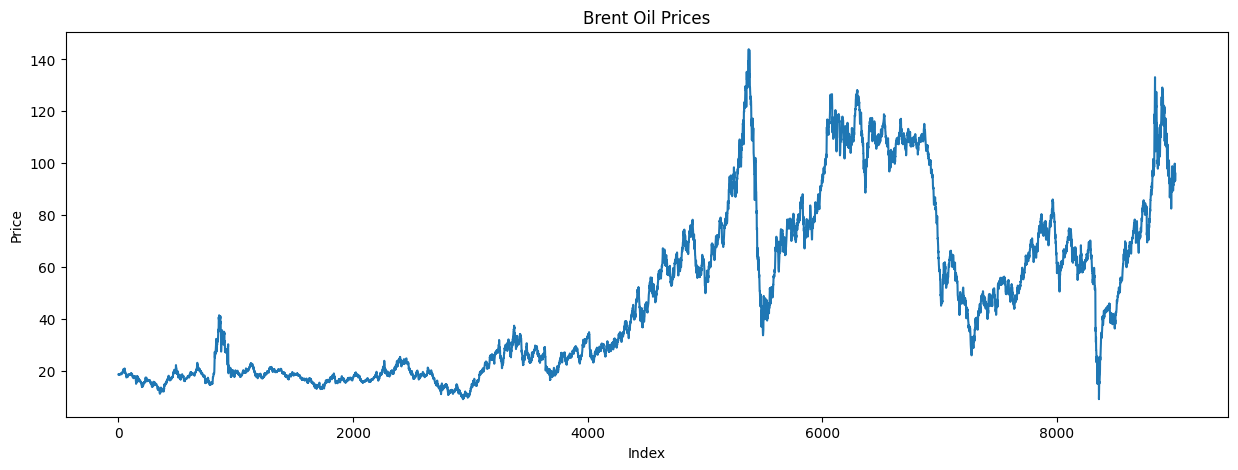

In [7]:
plt.figure(figsize=(15,5))
plt.plot(df['Price'])
plt.title('Brent Oil Prices')
plt.xlabel('Index')
plt.ylabel('Price')
plt.show()

Cek Nama Kolom Dataset

In [8]:
df.columns

Index(['Date', 'Price'], dtype='object')

Convert Tanggal

In [9]:
df['Date'] = pd.to_datetime(df['Date'])

C:\Users\WIGISS\AppData\Local\Temp\ipykernel_18128\2394721818.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


Cek Tipe Data

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9011 entries, 0 to 9010
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    9011 non-null   datetime64[ns]
 1   Price   9011 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 140.9 KB


Urutkan Berdasarkan Waktu

In [11]:
df = df.sort_values('Date')

Visualisasi Time Series

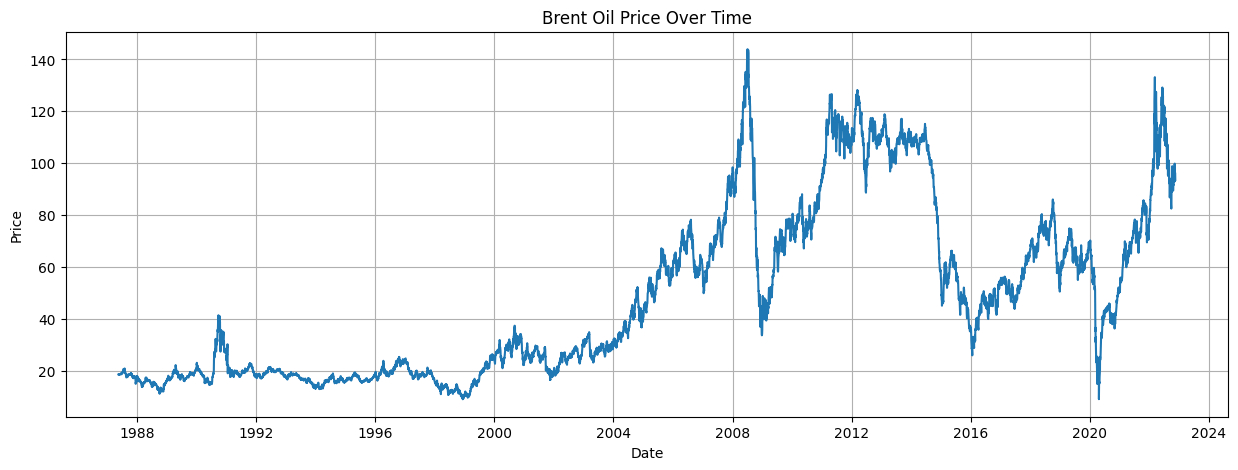

In [12]:
plt.figure(figsize=(15,5))
plt.plot(df['Date'], df['Price'])
plt.title('Brent Oil Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()

Ambil Kolom Price

In [13]:
data = df[['Price']]

Normalisasi Data

In [14]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

Split Data Train & Test

In [15]:
train_size = int(len(scaled_data) * 0.8)

train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

Buat Sequence Untuk LSTM

In [16]:
def create_dataset(dataset, time_step=30):
    X, y = [], []

    for i in range(len(dataset)-time_step-1):
        X.append(dataset[i:(i+time_step), 0])
        y.append(dataset[i + time_step, 0])

    return np.array(X), np.array(y)

Generate Data Training

In [17]:
time_step = 30

X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

Reshape Untuk LSTM

In [18]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)

X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

Cek Shape

In [19]:
print(X_train.shape)
print(X_test.shape)

(7177, 30, 1)
(1772, 30, 1)


LINEAR REGRESSION

Import Library Linear Regression

In [60]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Ubah Bentuk Data

Buat dan Training Model

Prediksi

Hitung Evaluasi

Visualisasi Hasil Prediks

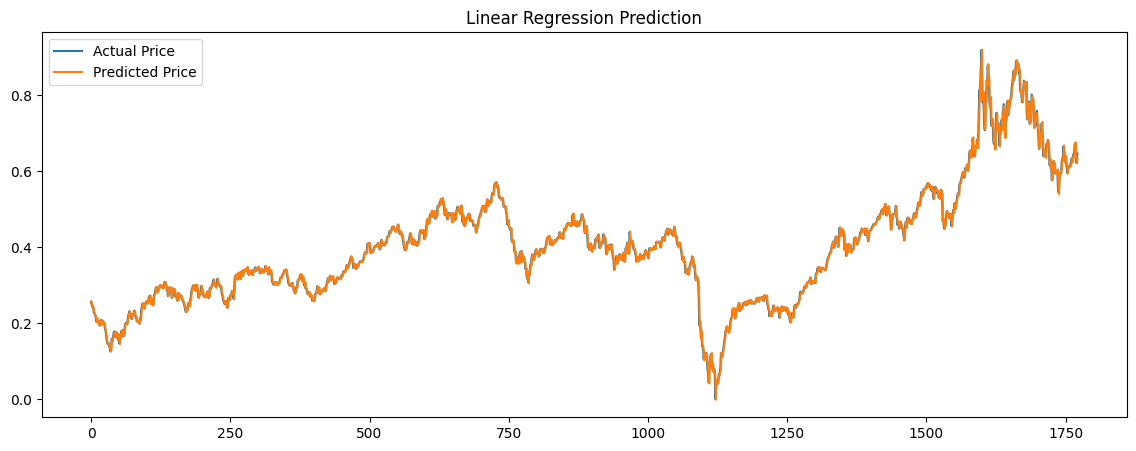

In [25]:
plt.figure(figsize=(14,5))

plt.plot(y_test, label='Actual Price')

plt.plot(lr_predictions, label='Predicted Price')

plt.title('Linear Regression Prediction')

plt.legend()

plt.show()

Simpan Hasil Evaluasi

In [26]:
results = {
    'Linear Regression': {
        'MAE': mae_lr,
        'RMSE': rmse_lr,
        'R2': r2_lr
    }
}

results

{'Linear Regression': {'MAE': 0.008480523187148557,
  'RMSE': 0.012761642787929768,
  'R2': 0.9930683907120733}}

ARTIFICIAL NEURAL NETWORK (ANN)

Import TensorFlow

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

Buat Model ANN

In [28]:
ann_model = Sequential()

ann_model.add(Dense(64, activation='relu', input_dim=X_train_lr.shape[1]))

ann_model.add(Dense(32, activation='relu'))

ann_model.add(Dense(1))

Compile Model

In [29]:
ann_model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

Training Model

In [30]:
history_ann = ann_model.fit(
    X_train_lr,
    y_train,
    validation_data=(X_test_lr, y_test),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
225/225 [==============================] - 1s 2ms/step - loss: 0.0022 - mae: 0.0226 - val_loss: 7.2662e-04 - val_mae: 0.0191
Epoch 2/50
225/225 [==============================] - 0s 1ms/step - loss: 3.2529e-04 - mae: 0.0117 - val_loss: 5.7110e-04 - val_mae: 0.0174
Epoch 3/50
225/225 [==============================] - 0s 1ms/step - loss: 2.2188e-04 - mae: 0.0097 - val_loss: 5.1765e-04 - val_mae: 0.0172
Epoch 4/50
225/225 [==============================] - 0s 1ms/step - loss: 1.9109e-04 - mae: 0.0090 - val_loss: 3.4616e-04 - val_mae: 0.0129
Epoch 5/50
225/225 [==============================] - 0s 1ms/step - loss: 1.9814e-04 - mae: 0.0091 - val_loss: 4.2546e-04 - val_mae: 0.0152
Epoch 6/50
225/225 [==============================] - 0s 1ms/step - loss: 1.7634e-04 - mae: 0.0086 - val_loss: 3.1436e-04 - val_mae: 0.0121
Epoch 7/50
225/225 [==============================] - 0s 1ms/step - loss: 1.6289e-04 - mae: 0.0081 - val_loss: 2.9863e-04 - val_mae: 0.0118
Epoch 8/50
225/225 [====

Prediksi ANN

In [31]:
ann_predictions = ann_model.predict(X_test_lr)

56/56 [==============================] - 0s 646us/step


Evaluasi ANN

In [32]:
mae_ann = mean_absolute_error(y_test, ann_predictions)

rmse_ann = np.sqrt(mean_squared_error(y_test, ann_predictions))

r2_ann = r2_score(y_test, ann_predictions)

print("MAE :", mae_ann)
print("RMSE :", rmse_ann)
print("R2 Score :", r2_ann)

MAE : 0.009988015731746017
RMSE : 0.014509423193129513
R2 Score : 0.9910397278118539


Visualisasi Prediksi ANN

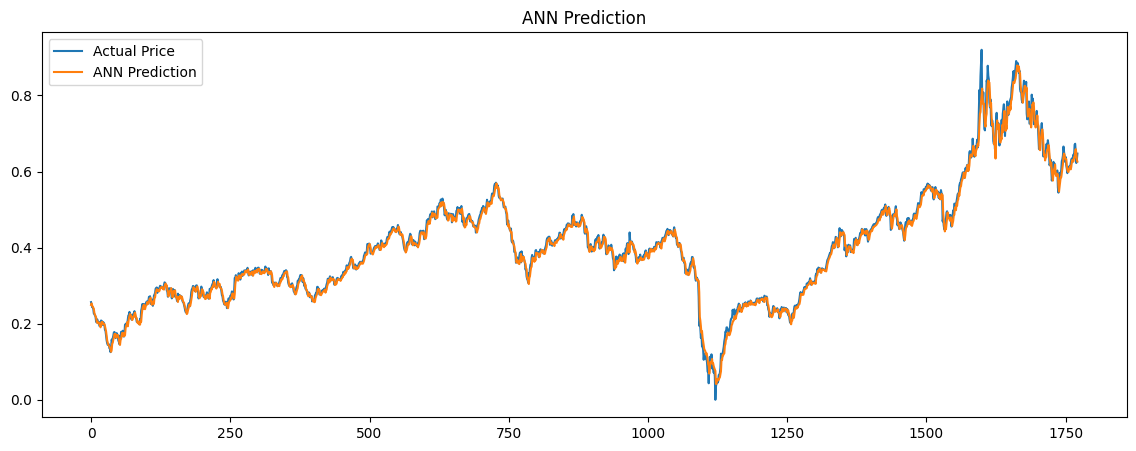

In [33]:
plt.figure(figsize=(14,5))

plt.plot(y_test, label='Actual Price')

plt.plot(ann_predictions, label='ANN Prediction')

plt.title('ANN Prediction')

plt.legend()

plt.show()

Visualisasi Loss Curve

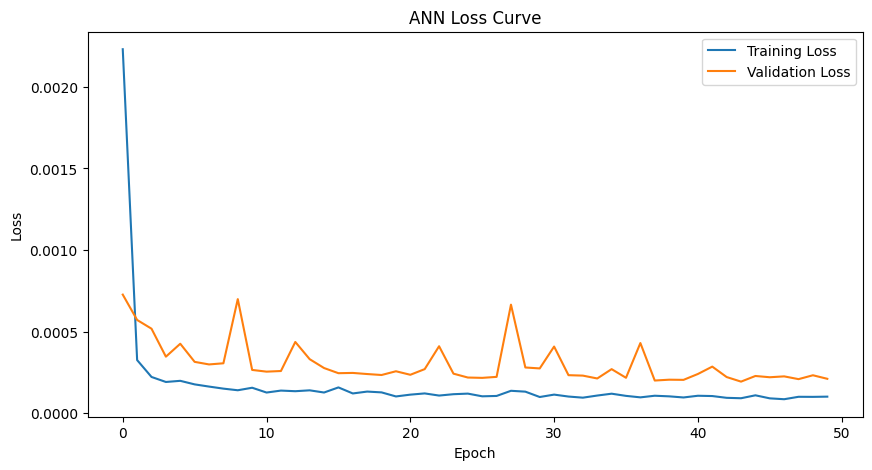

In [34]:
plt.figure(figsize=(10,5))

plt.plot(history_ann.history['loss'], label='Training Loss')

plt.plot(history_ann.history['val_loss'], label='Validation Loss')

plt.title('ANN Loss Curve')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.show()

Simpan Hasil ANN

In [35]:
results['ANN'] = {
    'MAE': mae_ann,
    'RMSE': rmse_ann,
    'R2': r2_ann
}

results

{'Linear Regression': {'MAE': 0.008480523187148557,
  'RMSE': 0.012761642787929768,
  'R2': 0.9930683907120733},
 'ANN': {'MAE': 0.009988015731746017,
  'RMSE': 0.014509423193129513,
  'R2': 0.9910397278118539}}

RNN/LSTM

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Normalisasi data
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df[['Price']])

# Membuat data sequence
X = []
y = []

time_step = 30

for i in range(time_step, len(scaled_data)):
    X.append(scaled_data[i-time_step:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

# Reshape untuk LSTM
X = X.reshape((X.shape[0], X.shape[1], 1))

print("Struktur data:", X.shape)

Struktur data: (8981, 30, 1)


In [37]:
# Split data training dan testing

split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (7184, 30, 1)
Testing : (1797, 30, 1)


MODEL LSTM

In [38]:
# Membuat model LSTM

model_lstm = Sequential([
    LSTM(50, return_sequences=False, input_shape=(X_train.shape[1], 1)),
    Dense(25),
    Dense(1)
])

model_lstm.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model_lstm.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 50)                10400     
                                                                 
 dense_3 (Dense)             (None, 25)                1275      
                                                                 
 dense_4 (Dense)             (None, 1)                 26        
                                                                 
Total params: 11,701
Trainable params: 11,701
Non-trainable params: 0
_________________________________________________________________


TRAINING LSTM

In [39]:
history_lstm = model_lstm.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/20
203/203 [==============================] - 3s 8ms/step - loss: 0.0049 - val_loss: 3.1270e-04
Epoch 2/20
203/203 [==============================] - 1s 7ms/step - loss: 2.0488e-04 - val_loss: 2.6515e-04
Epoch 3/20
203/203 [==============================] - 1s 6ms/step - loss: 1.9656e-04 - val_loss: 2.3320e-04
Epoch 4/20
203/203 [==============================] - 1s 7ms/step - loss: 1.6291e-04 - val_loss: 2.0417e-04
Epoch 5/20
203/203 [==============================] - 1s 6ms/step - loss: 1.6039e-04 - val_loss: 3.8613e-04
Epoch 6/20
203/203 [==============================] - 1s 6ms/step - loss: 1.6129e-04 - val_loss: 1.8824e-04
Epoch 7/20
203/203 [==============================] - 1s 6ms/step - loss: 1.3998e-04 - val_loss: 1.6179e-04
Epoch 8/20
203/203 [==============================] - 1s 6ms/step - loss: 1.2995e-04 - val_loss: 2.5226e-04
Epoch 9/20
203/203 [==============================] - 1s 6ms/step - loss: 1.1713e-04 - val_loss: 2.3084e-04
Epoch 10/20
203/203 [===========

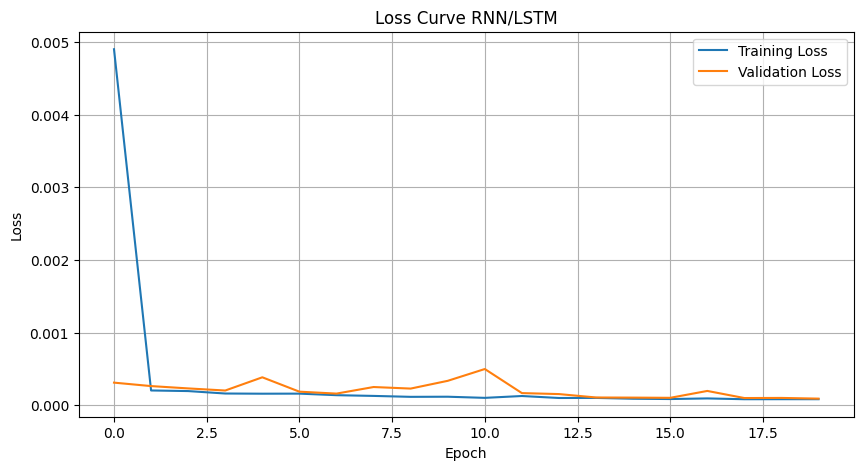

In [43]:
# Visualisasi Loss Curve RNN/LSTM

plt.figure(figsize=(10,5))

plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')

plt.title('Loss Curve RNN/LSTM')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.show()

PREDIKSI & EVALUASI

In [40]:
# Prediksi

pred_lstm = model_lstm.predict(X_test)

# Inverse transform
pred_lstm = scaler.inverse_transform(pred_lstm.reshape(-1,1))
y_test_real = scaler.inverse_transform(y_test.reshape(-1,1))

# Evaluasi
mae_lstm = mean_absolute_error(y_test_real, pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test_real, pred_lstm))

print("MAE :", mae_lstm)
print("RMSE :", rmse_lstm)

57/57 [==============================] - 0s 3ms/step
MAE : 1.235205397863287
RMSE : 1.8059384434856798


visualisasi

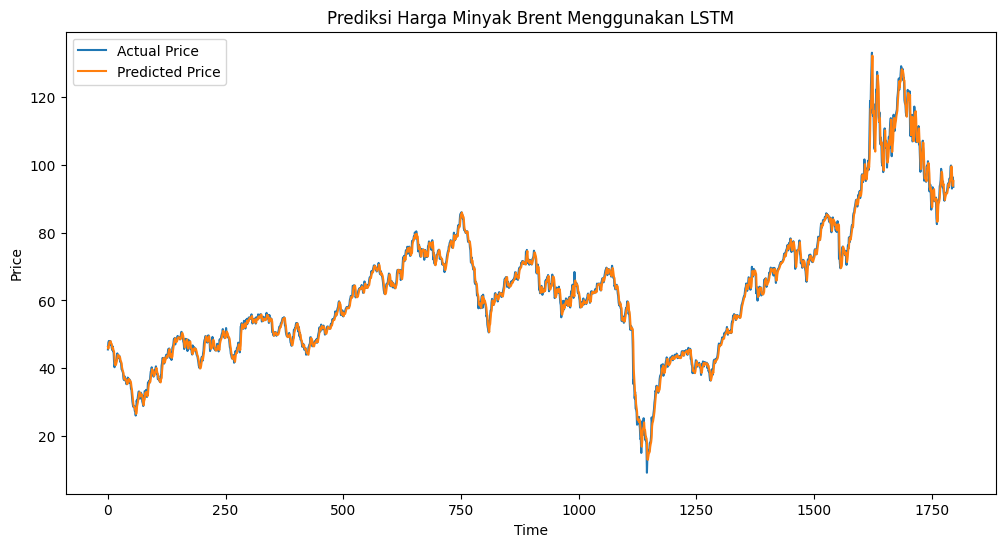

In [41]:
plt.figure(figsize=(12,6))

plt.plot(y_test_real, label='Actual Price')
plt.plot(pred_lstm, label='Predicted Price')

plt.title('Prediksi Harga Minyak Brent Menggunakan LSTM')
plt.xlabel('Time')
plt.ylabel('Price')

plt.legend()
plt.show()

Backpropagation

PREPARING DATA

In [44]:
# Data untuk Backpropagation Manual

X_bp = scaled_data[:-1]
y_bp = scaled_data[1:]

# Split data
split_bp = int(0.8 * len(X_bp))

X_train_bp = X_bp[:split_bp]
X_test_bp = X_bp[split_bp:]

y_train_bp = y_bp[:split_bp]
y_test_bp = y_bp[split_bp:]

print("Training Shape :", X_train_bp.shape)
print("Testing Shape  :", X_test_bp.shape)

Training Shape : (7208, 1)
Testing Shape  : (1802, 1)


AKTIVASI SIGMOID

In [45]:
# Fungsi Aktivasi Sigmoid

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Turunan sigmoid
def sigmoid_derivative(x):
    return x * (1 - x)

INISIALISASI BOBOT  

In [46]:
# Inisialisasi Bobot

np.random.seed(42)

input_neurons = 1
hidden_neurons = 5
output_neurons = 1

# Bobot input ke hidden
weights_input_hidden = np.random.rand(
    input_neurons,
    hidden_neurons
)

# Bobot hidden ke output
weights_hidden_output = np.random.rand(
    hidden_neurons,
    output_neurons
)

learning_rate = 0.01
epochs = 1000

Training Backpropagation Manual

In [47]:
# Training Backpropagation Manual

loss_history = []

for epoch in range(epochs):

    # FORWARD PROPAGATION
    hidden_input = np.dot(
        X_train_bp,
        weights_input_hidden
    )

    hidden_output = sigmoid(hidden_input)

    final_input = np.dot(
        hidden_output,
        weights_hidden_output
    )

    predicted_output = sigmoid(final_input)

    # ERROR
    error = y_train_bp - predicted_output

    loss = np.mean(np.abs(error))
    loss_history.append(loss)

    # BACKPROPAGATION
    d_predicted_output = (
        error *
        sigmoid_derivative(predicted_output)
    )

    error_hidden_layer = d_predicted_output.dot(
        weights_hidden_output.T
    )

    d_hidden_layer = (
        error_hidden_layer *
        sigmoid_derivative(hidden_output)
    )

    # UPDATE BOBOT
    weights_hidden_output += (
        hidden_output.T.dot(d_predicted_output)
        * learning_rate
    )

    weights_input_hidden += (
        X_train_bp.T.dot(d_hidden_layer)
        * learning_rate
    )

    # Print progress
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss}")

Epoch 0, Loss: 0.518528853552033
Epoch 100, Loss: 0.13552133814091324
Epoch 200, Loss: 0.017334944123718842
Epoch 300, Loss: 0.017353972027473245
Epoch 400, Loss: 0.01738868711832613
Epoch 500, Loss: 0.017419560177615236
Epoch 600, Loss: 0.01744040846408529
Epoch 700, Loss: 0.01745119286300987
Epoch 800, Loss: 0.017452789876093368
Epoch 900, Loss: 0.01744691566346226


VISUALISASI LOSS

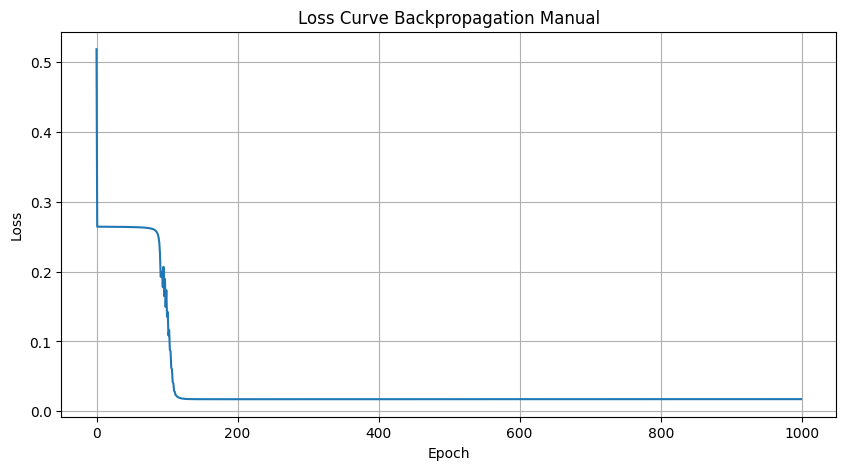

In [48]:
# Visualisasi Loss Backpropagation

plt.figure(figsize=(10,5))

plt.plot(loss_history)

plt.title('Loss Curve Backpropagation Manual')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.grid(True)

plt.show()

PREDIKSI & EVALUASI

In [49]:
# Testing

hidden_test = sigmoid(
    np.dot(X_test_bp, weights_input_hidden)
)

final_test = sigmoid(
    np.dot(hidden_test, weights_hidden_output)
)

# Inverse transform
pred_bp = scaler.inverse_transform(final_test)
y_real_bp = scaler.inverse_transform(y_test_bp)

# Evaluasi
mae_bp = mean_absolute_error(
    y_real_bp,
    pred_bp
)

rmse_bp = np.sqrt(
    mean_squared_error(
        y_real_bp,
        pred_bp
    )
)

print("MAE :", mae_bp)
print("RMSE :", rmse_bp)

MAE : 2.860385510161511
RMSE : 3.397382947883264


PERBANDINGAN MODEL

In [50]:
# Membuat DataFrame Perbandingan Model

comparison = {
    'Model': [
        'Linear Regression',
        'ANN',
        'RNN/LSTM',
        'Backpropagation'
    ],

    'MAE': [
        mae_lr,
        mae_ann,
        mae_lstm,
        mae_bp
    ],

    'RMSE': [
        rmse_lr,
        rmse_ann,
        rmse_lstm,
        rmse_bp
    ]
}

df_comparison = pd.DataFrame(comparison)

print(df_comparison)

               Model       MAE      RMSE
0  Linear Regression  0.008481  0.012762
1                ANN  0.009988  0.014509
2           RNN/LSTM  1.235205  1.805938
3    Backpropagation  2.860386  3.397383


VISUALISASI RMSE    

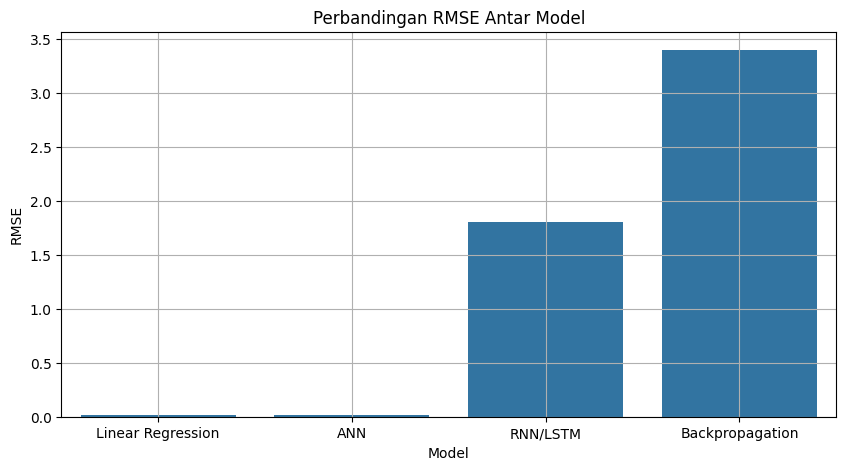

In [51]:
# Visualisasi RMSE

plt.figure(figsize=(10,5))

sns.barplot(
    x='Model',
    y='RMSE',
    data=df_comparison
)

plt.title('Perbandingan RMSE Antar Model')
plt.xlabel('Model')
plt.ylabel('RMSE')

plt.grid(True)

plt.show()

VISUALISASI MAE

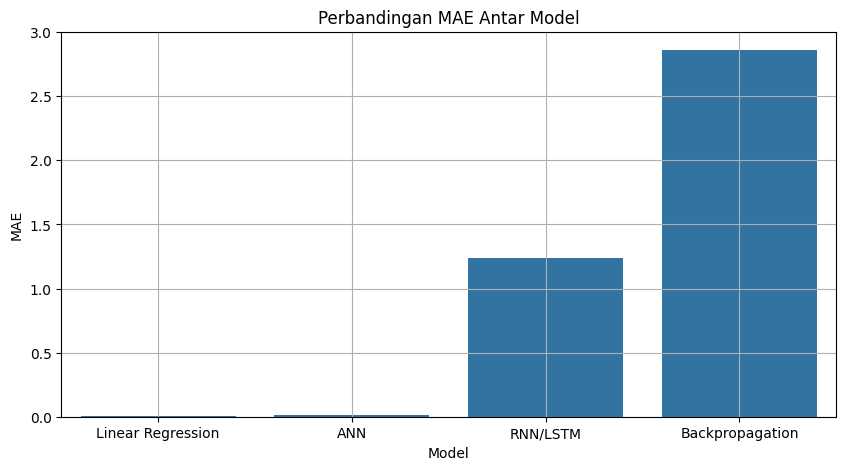

In [52]:
# Visualisasi MAE

plt.figure(figsize=(10,5))

sns.barplot(
    x='Model',
    y='MAE',
    data=df_comparison
)

plt.title('Perbandingan MAE Antar Model')
plt.xlabel('Model')
plt.ylabel('MAE')

plt.grid(True)

plt.show()

In [68]:
# Membuat ulang data untuk Linear Regression

X = df.index.values.reshape(-1, 1)
y = df['Price'].values

# Split data
from sklearn.model_selection import train_test_split

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [69]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Model
model_lr = LinearRegression()

# Training
model_lr.fit(X_train_lr, y_train_lr)

# Prediksi
y_pred_lr = model_lr.predict(X_test_lr)

# Evaluasi
mae_lr = mean_absolute_error(y_test_lr, y_pred_lr)
rmse_lr = mean_squared_error(y_test_lr, y_pred_lr) ** 0.5
r2_lr = r2_score(y_test_lr, y_pred_lr)

print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R2  :", r2_lr)

MAE : 17.306954927111097
RMSE: 22.48322043747179
R2  : 0.5405127650143109


In [53]:
import os

# Membuat folder models
if not os.path.exists('models'):
    os.makedirs('models')

print("Folder models berhasil dibuat.")

Folder models berhasil dibuat.


In [73]:
from sklearn.cluster import KMeans

# Membuat model KMeans
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

# Training KMeans
kmeans.fit(df[['Price']])

print("KMeans berhasil dibuat!")

KMeans berhasil dibuat!


In [65]:
import joblib

In [74]:
# Save Linear Regression
joblib.dump(
    model_lr,
    'models/linear_regression_model.pkl'
)

# Save KMeans
joblib.dump(
    kmeans,
    'models/kmeans_model.pkl'
)

# Save Scaler
joblib.dump(
    scaler,
    'models/scaler.pkl'
)

print("Model ML berhasil disimpan.")

Model ML berhasil disimpan.


In [76]:
# Save ANN
ann_model.save(
    'models/ann_model.h5'
)

# Save LSTM
model_lstm.save(
    'models/lstm_model.h5'
)

print("ANN & LSTM berhasil disimpan!")

ANN & LSTM berhasil disimpan!
